# Introduction/Theory

The objective is to find the ground state energy $E_0$ and the corresponding wavefunction $\psi(x)$ for a particle of mass $m=1$ in a potential $V(x) = x^4$. 

In natural units where $\hbar = 1$, the TISE is expressed as:

$$-\frac{1}{2} \frac{d^2\psi}{dx^2} + x^4\psi(x) = E\psi(x)$$

$\textbf{The Variational Principle}$

The variational principle states that for any trial wavefunction $\psi_{trial}$, the energy expectation value provides an upper bound to the true ground state energy:

$$E_{trial} = \langle \psi_{trial} | \hat{H} | \psi_{trial} \rangle \ge E_0$$

By minimizing the energy with respect to parameters like $\alpha$ or $\beta$, we approach the true ground state energy $E_0$.  

$\textbf{The Shooting Method and Boundary Conditions}$

For a bound state, the wavefunction must decay to zero as $|x| [cite_start]\to \infty$.

Because the quartic potential is symmetric ($V(x) = V(-x)$), the ground state has even parity, meaning $\psi(-x) = \psi(x)$ and $\psi'(0) = 0$. 

The "Shooting Method" treats energy $E$ as a variable, if $E$ is too high, $\psi(x_{max})$ diverges to $+\infty$, and if $E$ is too low, it diverges to $-\infty$.  


# Numerical Methods

$\textbf{Variational Integration}$

$\textbf{Normalization}$: The wavefunction is numerically normalized such that 

$\int |\psi|^2 dx = 1$

$\textbf{Potential Energy}$: Calculated via 

$\langle V \rangle = \int \psi^* x^4 \psi dx$

$\textbf{Kinetic Energy}$: To avoid numerical noise from second derivatives, integration by parts is used: 

$\langle T \rangle = \frac{1}{2} \int |\frac{d\psi}{dx}|^2 dx$

$\textbf{Optimization}$: A minimization algorithm is used to find the parameters $\alpha_{min}$ and $\beta_{min}$ that minimize the total energy 

$E = \langle T \rangle + \langle V \rangle$



### The Numerov Method and Initial Conditions

The Numerov method is a specialized 4th-order algorithm used for integrating second-order differential equations that lack a first-derivative term.

For the ground state of a symmetric potential, we assume **even parity**, which dictates our starting points:

1) **At the origin**: We set $\psi(0) = 1.0$

2) **Symmetry**: Because the ground state is symmetric, the first derivative at the origin must be zero ($\psi'(0) = 0$)

3) **Taylor Expansion**: Using these conditions, the second point $\psi_1$ (at $x = dx$) is derived via a Taylor expansion to allow the algorithm to begin:

$$\psi_1 = 1.0 + \frac{1}{2}k_0^2dx^2$$

where $k_0^2 = 2(E - V(0))$.

In [2]:
#code a)

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from scipy.optimize import minimize_scalar


x_var = np.linspace(-5, 5, 1001)

def get_energy(phi, x):
    
    norm = np.sqrt(simpson(y=np.abs(phi)**2, x=x))
    psi = phi / norm
    
    v_avg = simpson(y=psi**2 * x**4, x=x)
   
    dpsi_dx = np.gradient(psi, x)
    t_avg = 0.5 * simpson(y=dpsi_dx**2, x=x)
    
    return t_avg + v_avg

res_g = minimize_scalar(lambda a: get_energy(np.exp(-a * x_var**2), x_var), bounds=(0.2, 2.0))

res_q = minimize_scalar(lambda b: get_energy(np.exp(-b * x_var**4), x_var), bounds=(0.2, 2.0))

print(f"E_var1 (Gaussian): {res_g.fun:.5f} at alpha={res_g.x:.4f}")
print(f"E_var2 (Quartic): {res_q.fun:.5f} at beta={res_q.x:.4f}")

E_var1 (Gaussian): 0.68138 at alpha=0.9086
E_var2 (Quartic): 0.75688 at beta=0.4955


In [3]:
#code for b)

def k2_func(x, E):
    return 2 * (E - x**4)

def numerov(E):
    dx = 0.01
    x = np.arange(0, 4.0 + dx, dx)
    psi = np.zeros_like(x)
    
    
    psi[0] = 1.0
    psi[1] = 1.0 + 0.5 * k2_func(0, E) * dx**2 
    
    for n in range(1, len(x) - 1):
        k_prev, k_curr, k_next = k2_func(x[n-1], E), k2_func(x[n], E), k2_func(x[n+1], E)
        term1 = 2 * (1 - 5/12 * dx**2 * k_curr) * psi[n]
        term2 = (1 + 1/12 * dx**2 * k_prev) * psi[n-1]
        denom = 1 + 1/12 * dx**2 * k_next
        psi[n+1] = (term1 - term2) / denom
    return x, psi


def shooting_target(E):
    _, psi = numerov(E)
    return psi[-1]

from scipy.optimize import bisect
e_num = bisect(shooting_target, 0.5, 1.5)
print(f"Numerov Ground State Energy: {e_num:.4f}")

Numerov Ground State Energy: 0.6775


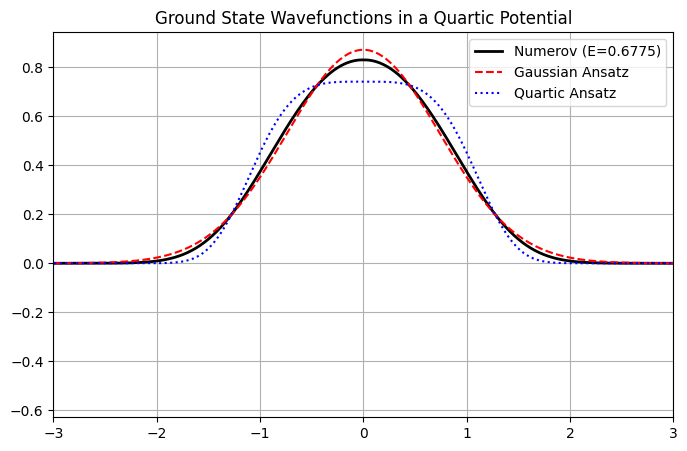

In [4]:
#code for c)


x_num_half, psi_num_half = numerov(e_num)
x_full = np.concatenate([-x_num_half[::-1], x_num_half[1:]])
psi_full = np.concatenate([psi_num_half[::-1], psi_num_half[1:]])
psi_num_norm = psi_full / np.sqrt(simpson(y=psi_full**2, x=x_full))

psi_g = np.exp(-res_g.x * x_full**2)
psi_g /= np.sqrt(simpson(y=psi_g**2, x=x_full))
psi_q = np.exp(-res_q.x * x_full**4)
psi_q /= np.sqrt(simpson(y=psi_q**2, x=x_full))

plt.figure(figsize=(8, 5))
plt.plot(x_full, psi_num_norm, 'k-', label=f'Numerov (E={e_num:.4f})', lw=2)
plt.plot(x_full, psi_g, 'r--', label='Gaussian Ansatz')
plt.plot(x_full, psi_q, 'b:', label='Quartic Ansatz')
plt.xlim(-3, 3); plt.legend(); plt.grid(True)
plt.title("Ground State Wavefunctions in a Quartic Potential")
plt.show()

# Analysis and Comparison of Results

### 1. Verification of the Variational Principle

Based on the numerical results obtained:

- **Variational (Gaussian)**: $E_{var1} \approx 0.68138$
- **Variational (Quartic)**: $E_{var2} \approx 0.75688$
- **Numerov (Numerical)**: $E_{num} \approx 0.6775$

These results **strictly obey the variational principle**, as both trial energies ($E_{var1}, E_{var2}$) act as an upper bound and are greater than the true ground state energy $E_{num}$ found via the Shooting method.

### 2. Wavefunction Shape and the Gaussian Ansatz

The Gaussian ansatz ($e^{-\alpha x^2}$) is the exact solution for a harmonic oscillator, but it fails to perfectly capture the true shape of the **quartic oscillator** for several reasons:

- **Potential Walls**: The $x^4$ potential has much steeper walls than a quadratic potential.
- **Probability Density**: As seen in the comparison plot, the Gaussian ansatz tends to **over-estimate** the probability density at the center ($x=0$).
- **Tails**: The true wavefunction for a quartic potential decays faster than a Gaussian in the tails because the potential energy grows more rapidly as $x$ increases.

### 3. Comparison of Trial Functions

The **Gaussian trial function** provided a lower energy bound than the **Quartic Exponential**, despite the potential itself being quartic. 

This suggests that the smooth, quadratic-like curvature of the wavefunction near the origin is a more critical feature for the ground state energy than the behavior in the extreme tails.

